<a href="https://colab.research.google.com/github/Ishana0/CartIntel/blob/main/notebooks/Mall_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('Mall_Customers.csv')
X = df.iloc[:, [3, 4]].values  # Annual Income and Spending Score

In [4]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

In [5]:
labels_map = {}
for i, center in enumerate(centers):
    income, spending = center[0], center[1]

    if income > 70 and spending > 70:
        labels_map[i] = {'name': 'Target (High Income, High Spend)', 'color': 'green'}
    elif income > 70 and spending < 40:
        labels_map[i] = {'name': 'Careful (High Income, Low Spend)', 'color': 'red'}
    elif income < 40 and spending > 70:
        labels_map[i] = {'name': 'Spendthrifts (Low Income, High Spend)', 'color': 'orange'}
    elif income < 40 and spending < 40:
        labels_map[i] = {'name': 'Sensible (Low Income, Low Spend)', 'color': 'cyan'}
    else:
        labels_map[i] = {'name': 'Standard (Middle Class)', 'color': 'blue'}

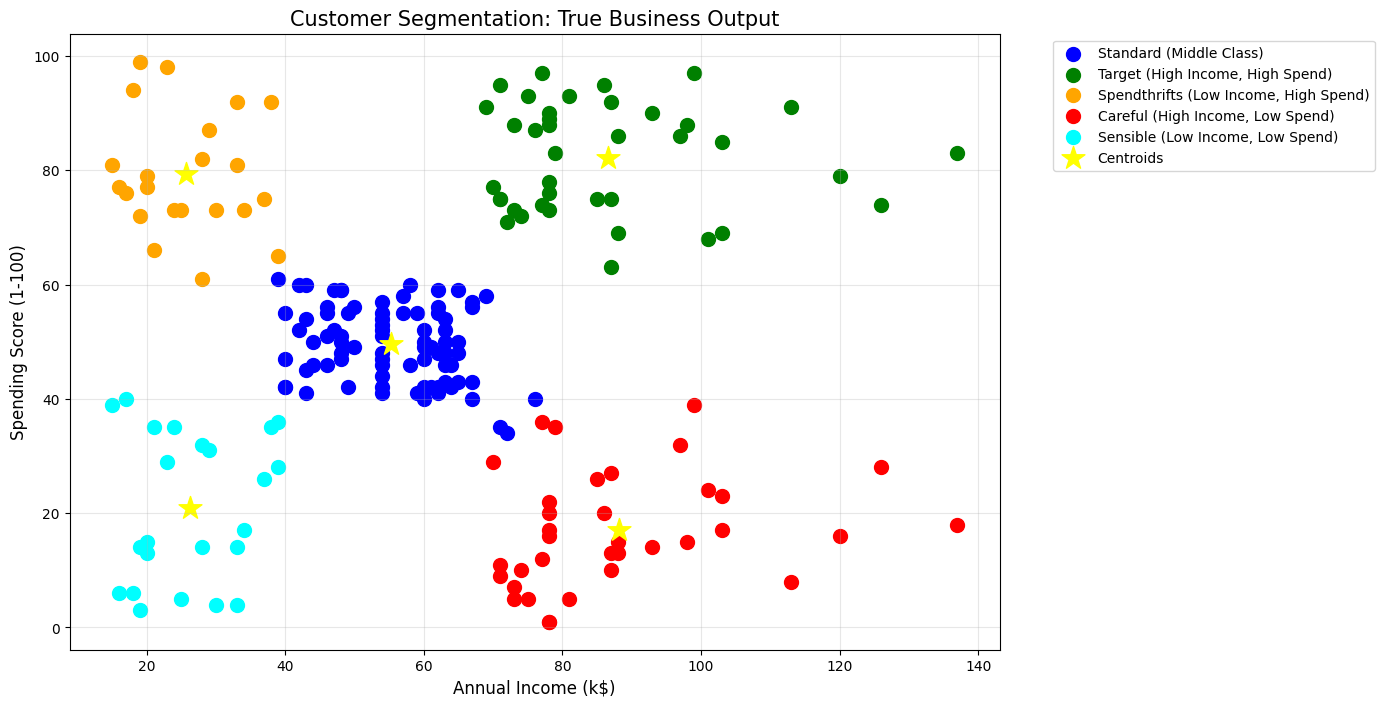

In [6]:
plt.figure(figsize=(12, 8))

for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=100, c=labels_map[i]['color'], label=labels_map[i]['name'])

# Plot Centroids
plt.scatter(centers[:, 0], centers[:, 1], s=300, c='yellow', marker='*', label='Centroids')

plt.title('Customer Segmentation: True Business Output', fontsize=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()